In [2]:
import arviz as az
import bayesflow as bf
import blackjax
import jax.numpy as jnp
import numpy as np

from confrdm.data import load_hdf5

INFO:2026-01-30 17:10:10,016:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [3]:
param_names = ["v_c_intercept", "v_c_slope", "s_true", "b", "t0"]

In [49]:
results = load_hdf5("../outputs/rdm/model.num_bins=12/model.num_mid=64/train_steps=50000/parameter_recovery.hdf5")
posterior_samples_chains = results["samples"]
posterior_samples = np.reshape(np.moveaxis(posterior_samples_chains, 1, -1), (posterior_samples_chains.shape[0], -1, len(param_names)))

prior_samples = results["true_params"]

In [50]:
posterior_samples.mean(axis=1)

array([[0.        , 4.2190948 , 0.910001  , 1.3931906 , 0.21187006],
       [0.        , 2.5866055 , 0.95269996, 1.0324041 , 0.        ],
       [0.10589432, 4.9291368 , 1.0274206 , 0.62131774, 0.60251355],
       [1.0062081 , 4.3079333 , 1.1763828 , 1.0389073 , 0.650395  ],
       [1.1018542 , 3.4168441 , 1.656531  , 0.8245417 , 0.5438831 ],
       [0.        , 4.000063  , 0.59923714, 1.5082666 , 0.76439923],
       [1.3332326 , 4.349322  , 0.88836926, 0.633303  , 0.23722619],
       [1.2664988 , 3.3776352 , 1.0880996 , 1.1460586 , 0.25066048],
       [0.        , 4.565733  , 0.8261255 , 0.58958846, 0.62512976],
       [1.1909587 , 3.6350362 , 0.9799108 , 1.5592978 , 0.43070668]],
      dtype=float32)

In [51]:
posterior_samples_chains.shape

(10, 5, 4, 1000)

In [52]:
prior_samples

array([[1.4690478 , 3.8531625 , 1.0936003 , 1.7375699 , 0.2110821 ],
       [0.08731467, 2.4101136 , 0.9731943 , 0.9664184 , 0.02387071],
       [0.32145464, 5.0797906 , 1.2139207 , 0.62466335, 0.6090256 ],
       [1.2245699 , 4.188082  , 1.1345987 , 1.1269493 , 0.63935566],
       [1.1588047 , 3.7034488 , 1.5923315 , 0.8933045 , 0.5348316 ],
       [1.4202486 , 3.5419    , 0.72585815, 1.9462175 , 0.7457888 ],
       [1.8997064 , 4.1475177 , 1.0187029 , 0.67423534, 0.2401911 ],
       [1.2291121 , 3.4064045 , 1.1147919 , 1.0474118 , 0.26645643],
       [1.5936213 , 4.1466603 , 0.8823552 , 0.82582486, 0.60546815],
       [1.1307517 , 3.747829  , 0.9894046 , 1.5318193 , 0.44540226]],
      dtype=float32)

In [53]:
blackjax.diagnostics.potential_scale_reduction(posterior_samples_chains, chain_axis=2, sample_axis=3)

Array([[       nan, 0.999953  , 1.0000975 , 0.9996166 , 0.9997223 ],
       [       nan, 1.0004925 , 1.0010101 , 1.0006574 ,        nan],
       [1.0796586 , 1.0136439 , 1.0086522 , 1.0448164 , 1.010176  ],
       [1.2875557 , 1.0202523 , 1.1009389 , 1.2251595 , 1.0424811 ],
       [1.0020152 , 0.99954826, 1.0009104 , 1.0016457 , 1.000485  ],
       [       nan, 1.0011092 , 1.0003551 , 1.0006846 , 0.9998006 ],
       [0.99953306, 1.0005909 , 0.9998704 , 0.99981374, 1.0001006 ],
       [1.0012469 , 0.9997802 , 1.0014045 , 1.000995  , 0.99958104],
       [       nan, 0.9996225 , 0.99975294, 0.99956334, 0.9997637 ],
       [1.0016592 , 1.0004076 , 1.0011157 , 1.0013899 , 1.0000087 ]],      dtype=float32)

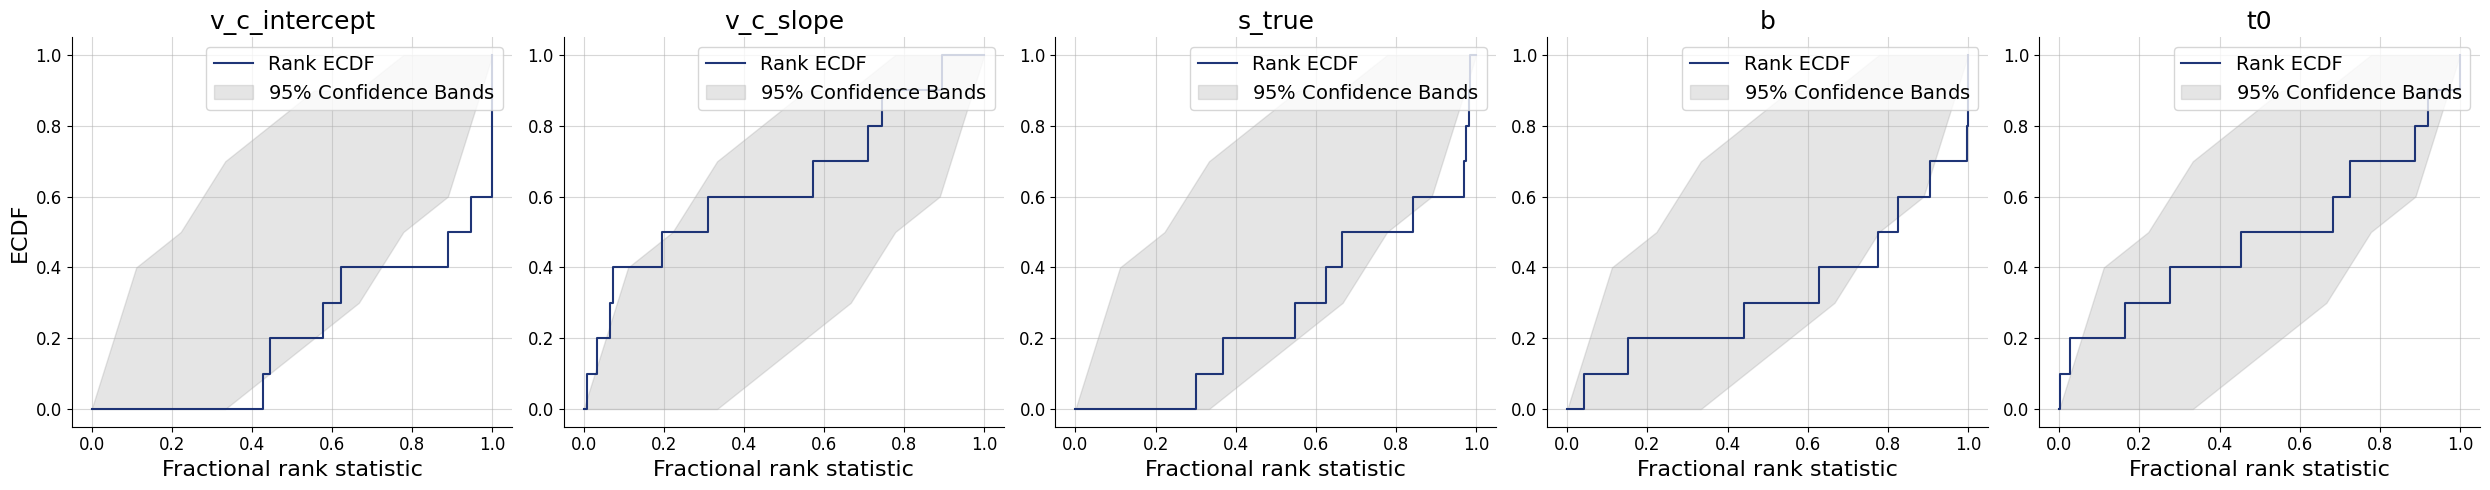

In [54]:
_ = bf.diagnostics.calibration_ecdf(posterior_samples, prior_samples, variable_names=param_names)

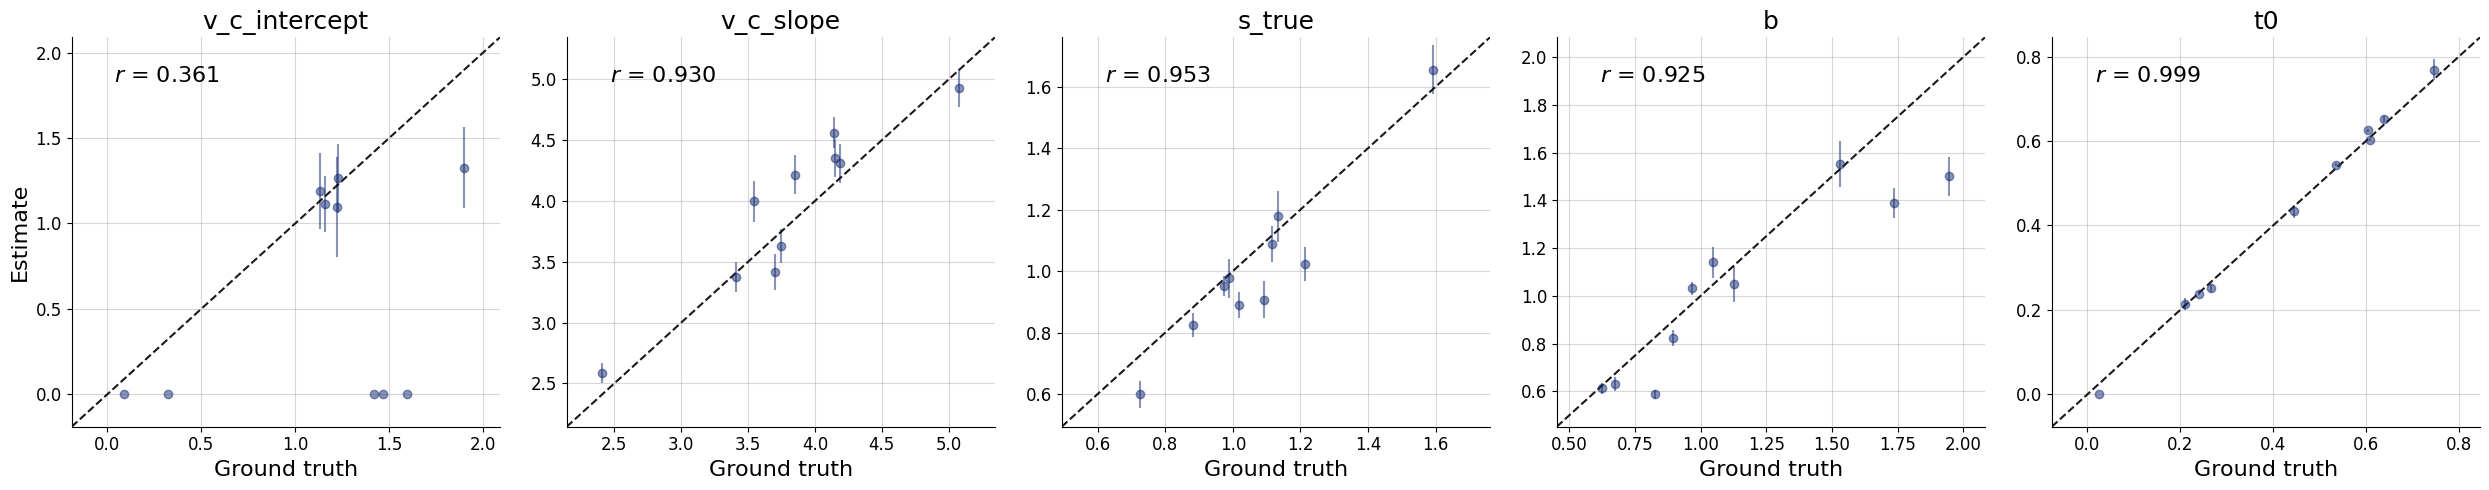

In [55]:
_ = bf.diagnostics.recovery(posterior_samples, prior_samples, variable_names=param_names)

In [30]:
results["true_params"].shape

(10, 5)